# HMS-to-RAS Boundary Condition Matching

This notebook demonstrates **correlation-based matching** between HEC-HMS DSS hydrograph outputs and HEC-RAS boundary condition locations using the **BaldEagleCrkMulti2D** example project.

**Problem**: HEC-RAS models use DSS-linked boundary conditions that reference HMS subbasin outputs. When models are modified or handed off, you need to verify that each RAS boundary condition is linked to the correct HMS hydrograph.

**Solution**: 
1. Extract DSS-linked boundary conditions from RAS unsteady flow files
2. Read the corresponding hydrographs from the HMS DSS file
3. Read the full DSS catalog and match RAS boundary paths to catalog entries
4. Compare hydrographs using correlation and NRMSE to validate linkage

**Example Project**: BaldEagleCrkMulti2D
- 10 unsteady flow files with DSS-linked boundary conditions
- `Bald_Eagle_Creek.dss` (30 MB, ~1270 records) with HMS hydrographs
- DSS boundaries: BALD EAGLE 40, FISHING CREEK, RESERVOIR LOCAL, LOCAL DOWNSTREAM OF DAM, MARSH CREEK

**Key Functions**:
- `RasDss.get_catalog()` - Read DSS file catalog
- `RasDss.read_timeseries()` - Extract time series from DSS
- `RasDss.extract_boundary_timeseries()` - Extract all DSS boundary data
- `RasHydroCompare.compare_hydrographs()` - Correlation and NRMSE comparison
- `RasHydroCompare.classify_match()` - Classify match quality

In [1]:
# =============================================================================
# DEVELOPMENT MODE TOGGLE
# =============================================================================
USE_LOCAL_SOURCE = True  # <-- TOGGLE THIS

if USE_LOCAL_SOURCE:
    import sys
    from pathlib import Path
    local_path = str(Path.cwd().parent)
    if local_path not in sys.path:
        sys.path.insert(0, local_path)
    print(f'LOCAL SOURCE MODE: Loading from {local_path}/ras_commander')
else:
    print('PIP PACKAGE MODE: Loading installed ras-commander')

# Import ras-commander
from ras_commander import (
    init_ras_project, RasExamples, RasUnsteady,
    RasDss, RasHydroCompare
)

# Additional imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Verify which version loaded
import ras_commander
print(f'Loaded: {ras_commander.__file__}')

LOCAL SOURCE MODE: Loading from <workspace>/ras_commander


Loaded: <workspace>\ras_commander\__init__.py


## Parameters

Configure project settings for this notebook.

In [2]:
# =============================================================================
# PARAMETERS - Edit these to customize the notebook
# =============================================================================

# Project Configuration
PROJECT_NAME = "BaldEagleCrkMulti2D"  # Example project with DSS boundary conditions
RAS_VERSION = "7.0"                    # HEC-RAS version
SUFFIX = "313"                         # Suffix for run folder

# DSS Configuration
DSS_FILENAME = "Bald_Eagle_Creek.dss"  # HMS DSS file with hydrographs
DSS_FLOW_FILTER = "/FLOW/"             # Filter for FLOW pathnames
DSS_RUN_FILTER = "PMF-EVENT"           # Filter for specific run (or None for all)

# Plan to analyze (plan with DSS-linked boundaries)
PLAN_NUMBER = "07"                     # Plan number with DSS boundaries

# JAVA_HOME for pyjnius/DSS access
import os
os.environ['JAVA_HOME'] = os.environ.get('JAVA_HOME', 'C:/tools/jdk17')

## Step 1: Extract Example Project

Extract the Bald Eagle Creek Multi-2D example project which has DSS-linked boundary conditions and a rich DSS file with HMS hydrographs.

In [3]:
# Extract example project
project_path = RasExamples.extract_project(PROJECT_NAME, suffix=SUFFIX)
print(f'Project extracted to: {project_path}')

2026-06-11 16:48:20 - ras_commander.RasExamples - INFO - Successfully extracted project 'BaldEagleCrkMulti2D' to <workspace>\examples\example_projects\BaldEagleCrkMulti2D_313


Project extracted to: <workspace>\examples\example_projects\BaldEagleCrkMulti2D_313


## Step 2: Initialize Project and Inspect Boundaries

Initialize the project and examine the `boundaries_df` to understand the boundary condition structure.

In [4]:
# Initialize project
ras = init_ras_project(project_path, RAS_VERSION)

print(f'Project: {ras.project_name}')
print(f'Plans: {len(ras.plan_df)}')
print(f'Unsteady files: {len(ras.unsteady_df)}')
print(f'Total Boundaries: {len(ras.boundaries_df)}')

# Show boundary type breakdown
print(f'\nBoundary Types:')
for bc_type, count in ras.boundaries_df['bc_type'].value_counts().items():
    print(f'  {bc_type}: {count}')

2026-06-11 16:48:20 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 7.0 at <hec_ras_install>\7.0\Ras.exe via filesystem (x86)


2026-06-11 16:48:20 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.7 Beta 5 at <hec_ras_install>\6.7 Beta 5\Ras.exe via filesystem (x86)


2026-06-11 16:48:20 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.6 at <hec_ras_install>\6.6\Ras.exe via filesystem (x86)


2026-06-11 16:48:20 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.5 at <hec_ras_install>\6.5\Ras.exe via filesystem (x86)


2026-06-11 16:48:20 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.4.1 at <hec_ras_install>\6.4.1\Ras.exe via filesystem (x86)


...

2026-06-11 16:48:20 - ras_commander.RasPrj - INFO - ras-commander v0.98.0 | An open-source project of CLB Engineering Corporation (https://clbengineering.com/) | Docs: https://rascommander.info | GitHub: https://github.com/gpt-cmdr/ras-commander


2026-06-11 16:48:20 - ras_commander.RasPrj - INFO - Project initialized: BaldEagleDamBrk | Folder: <workspace>\examples\example_projects\BaldEagleCrkMulti2D_313


2026-06-11 16:48:20 - ras_commander.RasPrj - INFO - Using HEC-RAS executable: <hec_ras_install>\7.0\Ras.exe


2026-06-11 16:48:20 - ras_commander.RasPrj - INFO - 
═══════════════════════════════════════════════════════════════════════
ras-commander | HEC-RAS Automation Library
Docs: https://rascommander.info/
Repo: https://github.com/gpt-cmdr/ras-commander
═══════════════════════════════════════════════════════════════════════

PROJECT DATAFRAMES (single source of truth — use these, not file globbing):
  ras.plan_df        Plans, HDF paths, geometry/flow associations
  ras.geom_df        Geometry files and HDF preprocessor paths
  ras.flow_df        Steady flow files
  ras.unsteady_df    Unsteady flow files and configurations
  ras.boundaries_df  Boundary conditions (type, name, location)
  ras.results_df     Lightweight HDF results summaries
  ras.rasmap_df      RASMapper layers, terrain, land cover paths

KEY APIS (static classes — call directly, never instantiate):
  Execution:    RasCmdr.compute_plan() / compute_parallel() / compute_test_mode()
  Plan Files:   RasPlan.clone_plan() / clone_

Project: BaldEagleDamBrk
Plans: 11
Unsteady files: 10
Total Boundaries: 51

Boundary Types:
  Normal Depth: 18
  Lateral Inflow Hydrograph: 11
  Gate Opening: 9
  Flow Hydrograph: 8
  Uniform Lateral Inflow Hydrograph: 5


## Step 3: Identify DSS-Linked Boundaries

Filter `boundaries_df` for DSS-linked boundary conditions. These are the boundaries we need to match against the HMS DSS file.

In [5]:
# Get all DSS-linked boundaries
all_dss_boundaries = ras.boundaries_df[ras.boundaries_df['Use DSS'] == 'True'].copy()

print(f'Total DSS-linked boundaries across all plans: {len(all_dss_boundaries)}')

# Show unique DSS A-parts (HMS subbasin names)
if 'dss_part_a' in all_dss_boundaries.columns:
    unique_subbasins = all_dss_boundaries['dss_part_a'].dropna().unique()
    print(f'\nUnique HMS Subbasins (from DSS A-part): {len(unique_subbasins)}')
    for name in sorted(unique_subbasins):
        count = (all_dss_boundaries['dss_part_a'] == name).sum()
        print(f'  {name} ({count} boundaries)')

# Focus on the target plan
plan_boundaries = ras.boundaries_df[ras.boundaries_df['unsteady_number'] == PLAN_NUMBER].copy()
dss_boundaries = plan_boundaries[plan_boundaries['Use DSS'] == 'True']

print(f'\nPlan {PLAN_NUMBER}:')
print(f'  Total boundaries: {len(plan_boundaries)}')
print(f'  DSS-linked boundaries: {len(dss_boundaries)}')

# Display DSS path components
if len(dss_boundaries) > 0:
    component_cols = ['bc_type', 'DSS Path', 'dss_part_a', 'dss_part_b', 'dss_part_d', 'dss_part_e']
    available_cols = [c for c in component_cols if c in dss_boundaries.columns]
    display(dss_boundaries[available_cols])

Total DSS-linked boundaries across all plans: 13

Unique HMS Subbasins (from DSS A-part): 7
  BALD EAGLE 40 (1 boundaries)
  BALD EAGLE LOCAL (2 boundaries)
  BEECH CREEK FLOW (2 boundaries)
  FISHING CREEK (3 boundaries)
  LOCAL DOWNSTREAM OF DAM (2 boundaries)
  MARSH CREEK (2 boundaries)
  RESERVOIR LOCAL (1 boundaries)

Plan 07:
  Total boundaries: 10
  DSS-linked boundaries: 7


,bc_type,DSS Path,dss_part_a,dss_part_b,dss_part_d,dss_part_e
0,Flow Hydrograph,//BALD EAGLE 40/FLOW/01JAN1999/15MIN/RUN:PMF-E...,BALD EAGLE 40,FLOW,15MIN,RUN:PMF-EVENT
2,Lateral Inflow Hydrograph,//FISHING CREEK/FLOW/01JAN1999/15MIN/RUN:PMF-E...,FISHING CREEK,FLOW,15MIN,RUN:PMF-EVENT
4,Uniform Lateral Inflow Hydrograph,//RESERVOIR LOCAL/FLOW/01JAN1999/15MIN/RUN:PMF...,RESERVOIR LOCAL,FLOW,15MIN,RUN:PMF-EVENT
5,Uniform Lateral Inflow Hydrograph,//LOCAL DOWNSTREAM OF DAM/FLOW/01JAN1999/15MIN...,LOCAL DOWNSTREAM OF DAM,FLOW,15MIN,RUN:PMF-EVENT
6,Lateral Inflow Hydrograph,//MARSH CREEK/FLOW/01JAN1999/15MIN/RUN:PMF-EVENT/,MARSH CREEK,FLOW,15MIN,RUN:PMF-EVENT
7,Lateral Inflow Hydrograph,//BEECH CREEK FLOW/FLOW/01JAN1999/15MIN/RUN:PM...,BEECH CREEK FLOW,FLOW,15MIN,RUN:PMF-EVENT
8,Uniform Lateral Inflow Hydrograph,//BALD EAGLE LOCAL/FLOW/01JAN1999/15MIN/RUN:PM...,BALD EAGLE LOCAL,FLOW,15MIN,RUN:PMF-EVENT


## Step 4: Read the HMS DSS Catalog

Read the full catalog from `Bald_Eagle_Creek.dss` and filter for FLOW pathnames. The DSS pathname structure is:

```
//A-part/B-part/C-part/D-part/E-part/F-part/
//[HMS_ELEMENT]/FLOW/[DATE]/[INTERVAL]/RUN:[EVENT_ID]/
```

**Part A (HMS element name) is the key for matching to RAS boundaries.**

In [6]:
# Get DSS file path
dss_file = project_path / DSS_FILENAME

if not dss_file.exists():
    raise FileNotFoundError(f'DSS file not found: {dss_file}')

print(f'DSS File: {dss_file.name}')
print(f'Size: {dss_file.stat().st_size / (1024*1024):.1f} MB')

# Read catalog
catalog_df = RasDss.get_catalog(dss_file)
print(f'\nTotal DSS pathnames: {len(catalog_df)}')

# Filter for FLOW pathnames
flow_catalog = catalog_df[catalog_df['pathname'].str.contains(DSS_FLOW_FILTER, na=False)]
print(f'FLOW pathnames: {len(flow_catalog)}')

# Further filter by run if specified
if DSS_RUN_FILTER:
    filtered_catalog = flow_catalog[flow_catalog['pathname'].str.contains(DSS_RUN_FILTER, na=False)]
    print(f'FLOW pathnames for \'{DSS_RUN_FILTER}\': {len(filtered_catalog)}')
else:
    filtered_catalog = flow_catalog

# Parse catalog pathnames into components
catalog_parsed = []
for pathname in filtered_catalog['pathname']:
    parts = pathname.strip('/').split('/')
    catalog_parsed.append({
        'pathname': pathname,
        'a_part': parts[0] if len(parts) > 0 else '',
        'b_part': parts[1] if len(parts) > 1 else '',
        'c_part': parts[2] if len(parts) > 2 else '',
        'd_part': parts[3] if len(parts) > 3 else '',
        'e_part': parts[4] if len(parts) > 4 else '',
    })

catalog_parsed_df = pd.DataFrame(catalog_parsed)
print(f'\nUnique HMS elements in DSS (A-part):')
for elem in sorted(catalog_parsed_df['a_part'].unique()):
    print(f'  {elem}')

DSS File: Bald_Eagle_Creek.dss
Size: 29.3 MB
Configuring Java VM for DSS operations...
[OK] Java VM configured



Total DSS pathnames: 1270
FLOW pathnames: 313
FLOW pathnames for 'PMF-EVENT': 52

Unique HMS elements in DSS (A-part):
  BALD EAGLE 10
  BALD EAGLE 20
  BALD EAGLE 30
  BALD EAGLE 40
  BALD EAGLE AT MILESBURG
  BALD EAGLE BL BEECH
  BALD EAGLE HW
  BALD EAGLE LOCAL
  BEECH CREEK
  BEECH CREEK FLOW
  BEECH CREEK GAGE
  BEECH CREEK LOWER
  BEECH CREEK UPPER
  FISHING CREEK
  FISHING CREEK CONFLUENCE
  JUNCTION-1
  LOCAL DOWNSTREAM OF DAM
  MARSH CREEK
  MARSH CREEK GAGE
  OUTLET
  POOL HW
  RESERVOIR LOCAL
  SAYERS DAM
  SAYERS DAM-SPILL-1
  SPRING CREEK
  SPRING CREEK GAGE


## Step 5: Match RAS Boundaries to DSS Catalog

Match each RAS DSS-linked boundary condition to its corresponding entry in the DSS catalog. The match is based on comparing the DSS path stored in the RAS unsteady file to the pathnames available in the DSS file.

In [7]:
# Match RAS boundaries to DSS catalog entries
match_results = []

for idx, bc_row in dss_boundaries.iterrows():
    dss_path = bc_row.get('DSS Path', '')
    a_part = bc_row.get('dss_part_a', '')
    bc_type = bc_row.get('bc_type', '')
    
    # Look for exact pathname match in catalog
    exact_match = catalog_df[catalog_df['pathname'] == dss_path]
    
    # Look for A-part match (HMS subbasin name) in FLOW catalog
    a_part_matches = catalog_parsed_df[catalog_parsed_df['a_part'] == a_part] if a_part else pd.DataFrame()
    
    match_results.append({
        'bc_type': bc_type,
        'dss_a_part': a_part,
        'dss_path': dss_path,
        'exact_match_found': len(exact_match) > 0,
        'a_part_flow_records': len(a_part_matches),
        'catalog_pathnames': list(a_part_matches['pathname']) if len(a_part_matches) > 0 else [],
    })

match_df = pd.DataFrame(match_results)

print('=== RAS Boundary to DSS Catalog Matching ===')
print(f'Total DSS boundaries: {len(match_df)}')
print(f'Exact path matches found: {match_df["exact_match_found"].sum()}')
print(f'A-part matches found: {(match_df["a_part_flow_records"] > 0).sum()}')
print()

for _, row in match_df.iterrows():
    status = 'FOUND' if row['exact_match_found'] else ('A-PART FOUND' if row['a_part_flow_records'] > 0 else 'NOT FOUND')
    print(f'  [{status}] {row["dss_a_part"]} ({row["bc_type"]})')
    print(f'    RAS DSS Path: {row["dss_path"]}')
    if row['a_part_flow_records'] > 0:
        print(f'    Catalog entries: {row["a_part_flow_records"]}')

=== RAS Boundary to DSS Catalog Matching ===
Total DSS boundaries: 7
Exact path matches found: 7
A-part matches found: 7

  [FOUND] BALD EAGLE 40 (Flow Hydrograph)
    RAS DSS Path: //BALD EAGLE 40/FLOW/01JAN1999/15MIN/RUN:PMF-EVENT/
    Catalog entries: 2
  [FOUND] FISHING CREEK (Lateral Inflow Hydrograph)
    RAS DSS Path: //FISHING CREEK/FLOW/01JAN1999/15MIN/RUN:PMF-EVENT/
    Catalog entries: 2
  [FOUND] RESERVOIR LOCAL (Uniform Lateral Inflow Hydrograph)
    RAS DSS Path: //RESERVOIR LOCAL/FLOW/01JAN1999/15MIN/RUN:PMF-EVENT/
    Catalog entries: 2
  [FOUND] LOCAL DOWNSTREAM OF DAM (Uniform Lateral Inflow Hydrograph)
    RAS DSS Path: //LOCAL DOWNSTREAM OF DAM/FLOW/01JAN1999/15MIN/RUN:PMF-EVENT/
    Catalog entries: 2
  [FOUND] MARSH CREEK (Lateral Inflow Hydrograph)
    RAS DSS Path: //MARSH CREEK/FLOW/01JAN1999/15MIN/RUN:PMF-EVENT/
    Catalog entries: 2
  [FOUND] BEECH CREEK FLOW (Lateral Inflow Hydrograph)
    RAS DSS Path: //BEECH CREEK FLOW/FLOW/01JAN1999/15MIN/RUN:PMF-EVENT/

## Step 6: Extract DSS Time Series for Boundaries

Read the actual hydrograph data from the DSS file for each DSS-linked boundary condition using `RasDss.extract_boundary_timeseries()`.

In [8]:
# Extract all DSS boundary time series for the target plan
enhanced_boundaries = RasDss.extract_boundary_timeseries(
    plan_boundaries,
    ras_object=ras
)

# Count successful extractions
dss_enhanced = enhanced_boundaries[enhanced_boundaries['Use DSS'] == 'True']
successful = dss_enhanced[dss_enhanced['dss_timeseries'].notna()]

print(f'=== DSS Time Series Extraction ===')
print(f'DSS boundaries in plan {PLAN_NUMBER}: {len(dss_enhanced)}')
print(f'Successfully extracted: {len(successful)}')
print()

# Show extraction summary
for idx, row in dss_enhanced.iterrows():
    ts = row.get('dss_timeseries')
    a_part = row.get('dss_part_a', 'Unknown')
    bc_type = row.get('bc_type', '')
    
    if ts is not None and len(ts) > 0:
        peak = ts['value'].max()
        n_points = len(ts)
        print(f'  {a_part} ({bc_type}): {n_points} points, peak = {peak:.1f}')
    else:
        print(f'  {a_part} ({bc_type}): NO DATA EXTRACTED')

2026-06-11 16:48:20 - ras_commander.dss.RasDss - INFO - Found 7 DSS-defined boundaries


2026-06-11 16:48:21 - ras_commander.dss.RasDss - INFO - Extraction complete: 7 success, 0 failed


=== DSS Time Series Extraction ===
DSS boundaries in plan 07: 7
Successfully extracted: 7

  BALD EAGLE 40 (Flow Hydrograph): 673 points, peak = 193738.2
  FISHING CREEK (Lateral Inflow Hydrograph): 673 points, peak = 28510.1
  RESERVOIR LOCAL (Uniform Lateral Inflow Hydrograph): 673 points, peak = 75262.3
  LOCAL DOWNSTREAM OF DAM (Uniform Lateral Inflow Hydrograph): 673 points, peak = 5568.2
  MARSH CREEK (Lateral Inflow Hydrograph): 673 points, peak = 37820.3
  BEECH CREEK FLOW (Lateral Inflow Hydrograph): 673 points, peak = 32872.2
  BALD EAGLE LOCAL (Uniform Lateral Inflow Hydrograph): 673 points, peak = 27428.2


## Step 7: Read DSS Catalog Time Series for Cross-Matching

Read FLOW time series from the DSS catalog for HMS elements that may not be directly linked to RAS boundaries. This allows cross-validation of all DSS entries against RAS boundary conditions.

In [9]:
# Read a selection of FLOW time series from the DSS catalog
# Focus on pathnames matching our run filter
dss_timeseries_catalog = {}
dss_metadata = []

sample_paths = filtered_catalog['pathname'].tolist()
print(f'Reading {len(sample_paths)} FLOW time series from DSS catalog...')

for pathname in sample_paths:
    try:
        ts_df = RasDss.read_timeseries(dss_file, pathname)
        
        # Parse pathname
        parts = pathname.strip('/').split('/')
        hms_element = parts[0] if len(parts) > 0 else 'Unknown'
        
        dss_timeseries_catalog[pathname] = ts_df['value'].values
        dss_metadata.append({
            'pathname': pathname,
            'hms_element': hms_element,
            'n_points': len(ts_df),
            'peak_flow': ts_df['value'].max(),
        })
    except Exception as e:
        print(f'  Warning: Could not read {pathname}: {e}')

dss_meta_df = pd.DataFrame(dss_metadata)
print(f'\nSuccessfully read: {len(dss_meta_df)} time series')
print(f'Unique HMS elements: {dss_meta_df["hms_element"].nunique()}')

# Show summary
print(f'\nHMS Element Summary:')
for elem in sorted(dss_meta_df['hms_element'].unique()):
    elem_data = dss_meta_df[dss_meta_df['hms_element'] == elem]
    print(f'  {elem}: {len(elem_data)} records, max peak = {elem_data["peak_flow"].max():.1f}')

Reading 52 FLOW time series from DSS catalog...



Successfully read: 52 time series
Unique HMS elements: 26

HMS Element Summary:
  BALD EAGLE 10: 2 records, max peak = 252903.0
  BALD EAGLE 20: 2 records, max peak = 234780.4
  BALD EAGLE 30: 2 records, max peak = 217744.6
  BALD EAGLE 40: 2 records, max peak = 193738.2
  BALD EAGLE AT MILESBURG: 2 records, max peak = 194325.9
  BALD EAGLE BL BEECH: 2 records, max peak = 249910.6
  BALD EAGLE HW: 2 records, max peak = 106592.7
  BALD EAGLE LOCAL: 2 records, max peak = 27428.2
  BEECH CREEK: 2 records, max peak = 30765.7
  BEECH CREEK FLOW: 2 records, max peak = 32872.2
  BEECH CREEK GAGE: 2 records, max peak = 32458.3
  BEECH CREEK LOWER: 2 records, max peak = 14217.8
  BEECH CREEK UPPER: 2 records, max peak = 32458.3
  FISHING CREEK: 2 records, max peak = 28510.1
  FISHING CREEK CONFLUENCE: 2 records, max peak = 257734.4
  JUNCTION-1: 2 records, max peak = 222289.3
  LOCAL DOWNSTREAM OF DAM: 2 records, max peak = 5568.2
  MARSH CREEK: 2 records, max peak = 37820.3
  MARSH CREEK GAGE

## Step 8: Correlation-Based Matching

For each extracted RAS boundary hydrograph, compare against ALL DSS catalog hydrographs using `RasHydroCompare.compare_hydrographs()`. This validates that the DSS links point to the correct HMS output.

**Match Quality Classification** (`RasHydroCompare.classify_match()`):
- **EXACT**: r > 0.9999, NRMSE < 0.01% (identical data)
- **CLOSE**: r > 0.99, NRMSE < 1.0% (minor rounding differences)
- **POSSIBLE**: r > 0.95, NRMSE < 5.0% (similar shape, different magnitude)
- **MISMATCH**: Below thresholds

In [10]:
# Compare each RAS boundary hydrograph to DSS catalog entries
comparison_results = []

for idx, bc_row in successful.iterrows():
    ts_data = bc_row['dss_timeseries']
    if ts_data is None or len(ts_data) == 0:
        continue
    
    bc_flow = ts_data['value'].values
    a_part = bc_row.get('dss_part_a', 'Unknown')
    bc_type = bc_row.get('bc_type', '')
    dss_path_ras = bc_row.get('DSS Path', '')
    
    best_match = None
    best_corr = -1
    
    for pathname, dss_flow in dss_timeseries_catalog.items():
        # Compare hydrographs
        result = RasHydroCompare.compare_hydrographs(
            bc_flow, dss_flow, truncate_to_shorter=True
        )
        
        # Track best match
        if result['correlation'] > best_corr:
            best_corr = result['correlation']
            best_match = {
                'ras_a_part': a_part,
                'ras_bc_type': bc_type,
                'ras_dss_path': dss_path_ras,
                'ras_peak': float(np.max(bc_flow)),
                'best_dss_pathname': pathname,
                'best_hms_element': pathname.strip('/').split('/')[0],
                'correlation': result['correlation'],
                'nrmse_pct': result['nrmse_pct'],
                'peak_diff': result['peak_diff'],
                'peak_ratio': result['peak_ratio'],
                'quality': RasHydroCompare.classify_match(
                    result['correlation'], result['nrmse_pct']
                ),
            }
    
    if best_match:
        comparison_results.append(best_match)

comparison_df = pd.DataFrame(comparison_results)

print('=== Correlation-Based Matching Results ===')
print(f'Boundaries compared: {len(comparison_df)}')
print()

# Show quality distribution
if len(comparison_df) > 0:
    print('Match Quality Distribution:')
    for quality, count in comparison_df['quality'].value_counts().items():
        pct = count / len(comparison_df) * 100
        print(f'  {quality}: {count} ({pct:.0f}%)')
    
    print(f'\nDetailed Results:')
    print('-' * 100)
    for _, row in comparison_df.iterrows():
        linked_match = row['ras_a_part'] == row['best_hms_element']
        link_status = 'CONFIRMED' if linked_match and row['quality'] in ('EXACT', 'CLOSE') else 'CHECK'
        print(f'  [{row["quality"]:8s}] {row["ras_a_part"]}')
        print(f'    Linked DSS path: {row["ras_dss_path"]}')
        print(f'    Best match:      {row["best_dss_pathname"]}')
        print(f'    Correlation: {row["correlation"]:.6f}, NRMSE: {row["nrmse_pct"]:.4f}%')
        print(f'    Peak ratio: {row["peak_ratio"]:.4f}, Link status: {link_status}')
        print()

=== Correlation-Based Matching Results ===
Boundaries compared: 7

Match Quality Distribution:
  EXACT: 7 (100%)

Detailed Results:
----------------------------------------------------------------------------------------------------
  [EXACT   ] BALD EAGLE 40
    Linked DSS path: //BALD EAGLE 40/FLOW/01JAN1999/15MIN/RUN:PMF-EVENT/
    Best match:      //BALD EAGLE 40/FLOW/01JAN1999/15MIN/RUN:PMF-EVENT/
    Correlation: 1.000000, NRMSE: 0.0000%
    Peak ratio: 1.0000, Link status: CONFIRMED

  [EXACT   ] FISHING CREEK
    Linked DSS path: //FISHING CREEK/FLOW/01JAN1999/15MIN/RUN:PMF-EVENT/
    Best match:      //FISHING CREEK/FLOW/01JAN1999/15MIN/RUN:PMF-EVENT/
    Correlation: 1.000000, NRMSE: 0.0000%
    Peak ratio: 1.0000, Link status: CONFIRMED

  [EXACT   ] RESERVOIR LOCAL
    Linked DSS path: //RESERVOIR LOCAL/FLOW/01JAN1999/15MIN/RUN:PMF-EVENT/
    Best match:      //RESERVOIR LOCAL/FLOW/01JAN1999/15MIN/RUN:PMF-EVENT/
    Correlation: 1.000000, NRMSE: 0.0000%
    Peak ratio: 1.00

## Step 9: Validate DSS Links

For DSS-linked boundaries, the primary validation is confirming that the DSS path in the RAS unsteady file points to the correct HMS element. An EXACT or CLOSE match between the boundary's own DSS time series and its best catalog match confirms correct linkage.

In [11]:
# Validate that each boundary's DSS link is correct
print('=== DSS Link Validation Summary ===\n')

confirmed = 0
mismatched = 0
unverified = 0

for _, row in comparison_df.iterrows():
    is_self_match = row['ras_a_part'] == row['best_hms_element']
    quality = row['quality']
    
    if is_self_match and quality in ('EXACT', 'CLOSE'):
        confirmed += 1
        status = 'CONFIRMED'
    elif is_self_match and quality == 'POSSIBLE':
        unverified += 1
        status = 'NEEDS REVIEW'
    else:
        mismatched += 1
        status = 'MISMATCH'
    
    print(f'  {row["ras_a_part"]:30s} -> {row["best_hms_element"]:30s}  [{status}]')
    if not is_self_match:
        print(f'    WARNING: Best match is a different HMS element!')
        print(f'    Expected: {row["ras_a_part"]}, Got: {row["best_hms_element"]}')
        print(f'    Correlation: {row["correlation"]:.6f}')

print(f'\n--- Summary ---')
print(f'  Confirmed correct links: {confirmed}')
print(f'  Needs review:            {unverified}')
print(f'  Potential mismatches:     {mismatched}')
print(f'  Total:                    {len(comparison_df)}')

=== DSS Link Validation Summary ===

  BALD EAGLE 40                  -> BALD EAGLE 40                   [CONFIRMED]
  FISHING CREEK                  -> FISHING CREEK                   [CONFIRMED]
  RESERVOIR LOCAL                -> RESERVOIR LOCAL                 [CONFIRMED]
  LOCAL DOWNSTREAM OF DAM        -> LOCAL DOWNSTREAM OF DAM         [CONFIRMED]
  MARSH CREEK                    -> MARSH CREEK                     [CONFIRMED]
  BEECH CREEK FLOW               -> BEECH CREEK FLOW                [CONFIRMED]
  BALD EAGLE LOCAL               -> BALD EAGLE LOCAL                [CONFIRMED]

--- Summary ---
  Confirmed correct links: 7
  Needs review:            0
  Potential mismatches:     0
  Total:                    7


## Step 10: Visualize Matched Hydrographs

Create comparison plots showing the RAS boundary hydrograph overlaid with its best-matching DSS catalog entry.

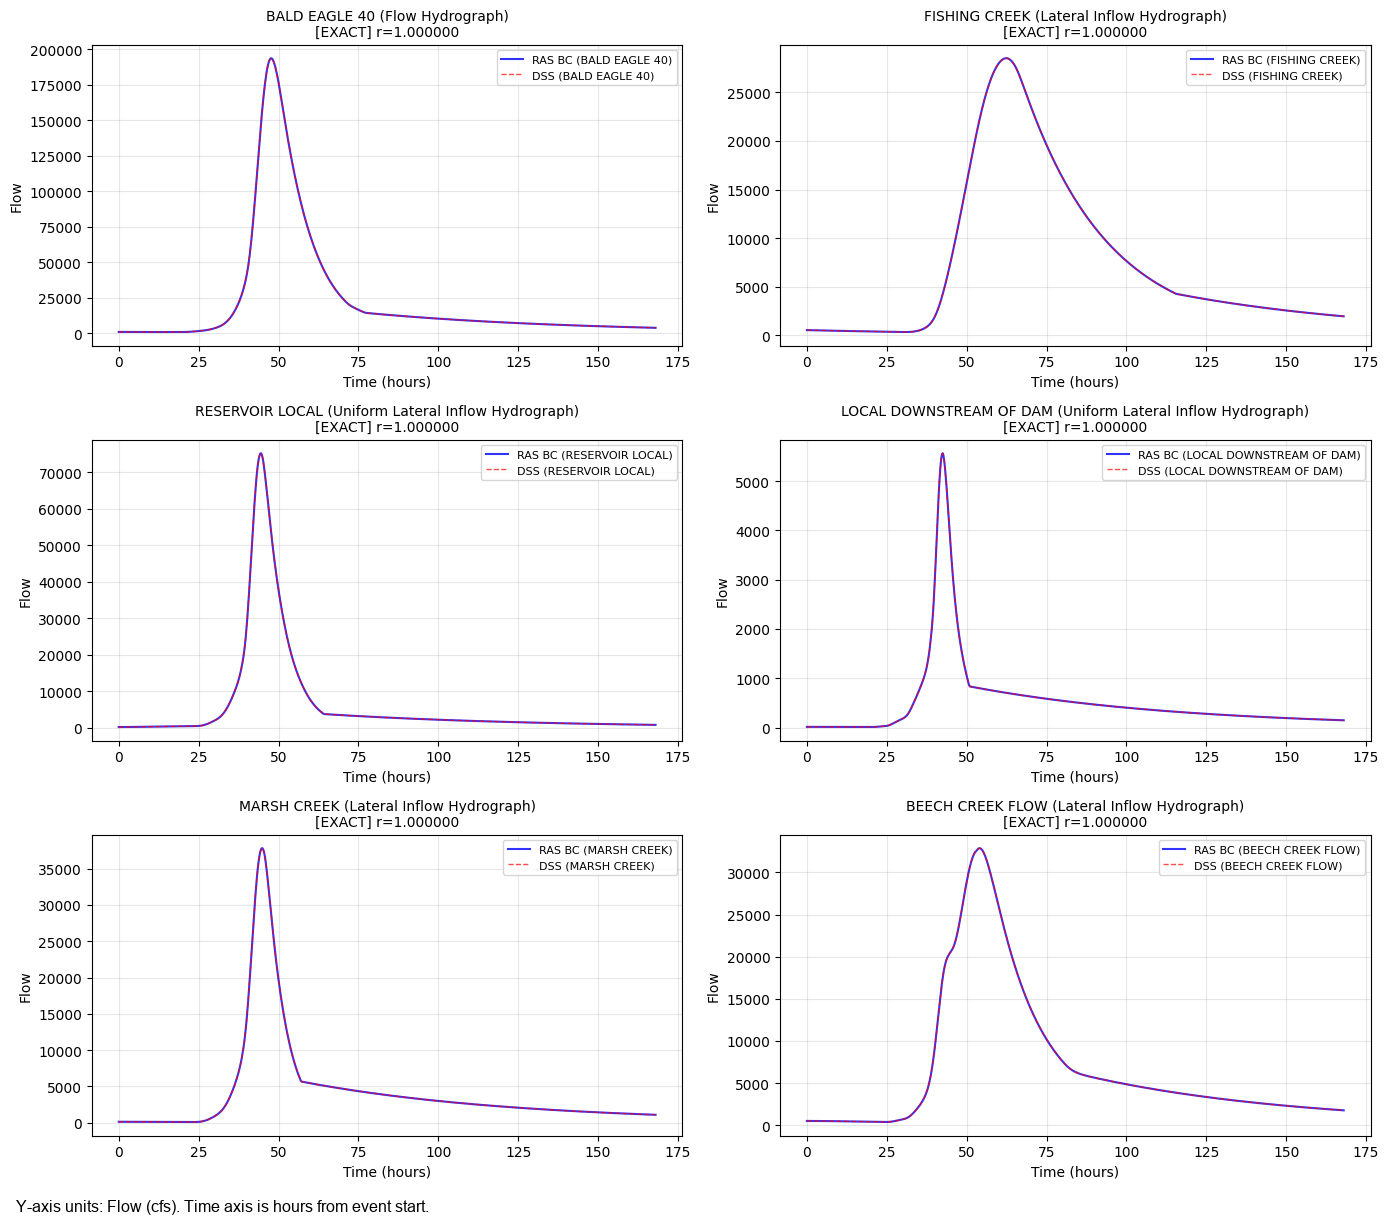

Plots saved to: <workspace>\examples\example_projects\BaldEagleCrkMulti2D_313\boundary_matching_plots.png


In [12]:
# Plot hydrograph comparisons
n_plots = min(len(successful), 6)
if n_plots == 0:
    print('No successful DSS extractions to plot.')
else:
    n_cols = min(n_plots, 2)
    n_rows = (n_plots + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
    if n_plots == 1:
        axes = np.array([axes])
    axes = np.array(axes).flatten()
    
    plot_idx = 0
    for idx, bc_row in successful.iterrows():
        if plot_idx >= n_plots:
            break
        
        ts_data = bc_row['dss_timeseries']
        if ts_data is None or len(ts_data) == 0:
            continue
        
        ax = axes[plot_idx]
        bc_flow = ts_data['value'].values
        a_part = bc_row.get('dss_part_a', 'Unknown')
        bc_type = bc_row.get('bc_type', '')
        
        # Find best match from comparison results
        match_row = comparison_df[comparison_df['ras_a_part'] == a_part]
        
        # Plot RAS boundary hydrograph
        time_hrs = np.arange(len(bc_flow)) * 15 / 60  # Assume 15-min intervals
        ax.plot(time_hrs, bc_flow, 'b-', linewidth=1.5, label=f'RAS BC ({a_part})', alpha=0.8)
        
        # Overlay best DSS match if available
        if len(match_row) > 0:
            best_pathname = match_row.iloc[0]['best_dss_pathname']
            if best_pathname in dss_timeseries_catalog:
                dss_flow = dss_timeseries_catalog[best_pathname]
                min_len = min(len(bc_flow), len(dss_flow))
                dss_time = np.arange(min_len) * 15 / 60
                ax.plot(dss_time, dss_flow[:min_len], 'r--', linewidth=1.0,
                       label=f'DSS ({match_row.iloc[0]["best_hms_element"]})', alpha=0.7)
            
            quality = match_row.iloc[0]['quality']
            corr = match_row.iloc[0]['correlation']
            ax.set_title(f'{a_part} ({bc_type})\n[{quality}] r={corr:.6f}', fontsize=10)
        else:
            ax.set_title(f'{a_part} ({bc_type})', fontsize=10)
        
        ax.set_xlabel('Time (hours)')
        ax.set_ylabel('Flow')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        
        plot_idx += 1
    
    # Hide unused axes
    for i in range(plot_idx, len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.savefig(project_path / 'boundary_matching_plots.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Plots saved to: {project_path / "boundary_matching_plots.png"}')

## Step 11: Cross-Plan Boundary Comparison

Compare boundary conditions across multiple unsteady flow files to identify which plans share the same HMS inputs.

In [13]:
# Analyze boundaries across all plans
print('=== Cross-Plan Boundary Analysis ===\n')

# Group by unsteady file
for unsteady_num in sorted(ras.boundaries_df['unsteady_number'].unique()):
    plan_bcs = ras.boundaries_df[ras.boundaries_df['unsteady_number'] == unsteady_num]
    dss_bcs = plan_bcs[plan_bcs['Use DSS'] == 'True']
    manual_bcs = plan_bcs[plan_bcs['Use DSS'] != 'True']
    
    # Get inline hydrograph count
    inline_count = 0
    unsteady_files = ras.unsteady_df[ras.unsteady_df['unsteady_number'] == unsteady_num]
    if len(unsteady_files) > 0:
        u_path = unsteady_files.iloc[0]['full_path']
        try:
            inline_bcs = RasUnsteady.get_inline_hydrograph_boundaries(u_path)
            inline_count = len(inline_bcs)
        except Exception:
            pass
    
    print(f'Unsteady {unsteady_num}: {len(plan_bcs)} total BCs')
    print(f'  DSS-linked: {len(dss_bcs)}')
    print(f'  Manual/other: {len(manual_bcs)}')
    if inline_count > 0:
        print(f'  Inline hydrographs: {inline_count}')
    
    if len(dss_bcs) > 0 and 'dss_part_a' in dss_bcs.columns:
        subbasins = dss_bcs['dss_part_a'].dropna().unique()
        print(f'  HMS subbasins: {", ".join(sorted(subbasins))}')
    print()

2026-06-11 16:48:22 - ras_commander.RasUnsteady - INFO - Found 1 inline hydrograph boundaries in BaldEagleDamBrk.u01


2026-06-11 16:48:22 - ras_commander.RasUnsteady - INFO - Found 1 inline hydrograph boundaries in BaldEagleDamBrk.u02


2026-06-11 16:48:22 - ras_commander.RasUnsteady - INFO - Found 1 inline hydrograph boundaries in BaldEagleDamBrk.u03


2026-06-11 16:48:22 - ras_commander.RasUnsteady - INFO - Found 1 inline hydrograph boundaries in BaldEagleDamBrk.u07


2026-06-11 16:48:22 - ras_commander.RasUnsteady - INFO - Found 2 inline hydrograph boundaries in BaldEagleDamBrk.u08


...

2026-06-11 16:48:22 - ras_commander.RasUnsteady - INFO - Found 1 inline hydrograph boundaries in BaldEagleDamBrk.u10


2026-06-11 16:48:22 - ras_commander.RasUnsteady - INFO - Found 1 inline hydrograph boundaries in BaldEagleDamBrk.u11


2026-06-11 16:48:22 - ras_commander.RasUnsteady - INFO - Found 1 inline hydrograph boundaries in BaldEagleDamBrk.u12


2026-06-11 16:48:22 - ras_commander.RasUnsteady - INFO - Found 1 inline hydrograph boundaries in BaldEagleDamBrk.u13


=== Cross-Plan Boundary Analysis ===

Unsteady 01: 4 total BCs
  DSS-linked: 0
  Manual/other: 4
  Inline hydrographs: 1

Unsteady 02: 5 total BCs
  DSS-linked: 0
  Manual/other: 5
  Inline hydrographs: 1

Unsteady 03: 4 total BCs
  DSS-linked: 0
  Manual/other: 4
  Inline hydrographs: 1

Unsteady 07: 10 total BCs
  DSS-linked: 7
  Manual/other: 3
  Inline hydrographs: 1
  HMS subbasins: BALD EAGLE 40, BALD EAGLE LOCAL, BEECH CREEK FLOW, FISHING CREEK, LOCAL DOWNSTREAM OF DAM, MARSH CREEK, RESERVOIR LOCAL

Unsteady 08: 9 total BCs
  DSS-linked: 5
  Manual/other: 4
  Inline hydrographs: 2
  HMS subbasins: BALD EAGLE LOCAL, BEECH CREEK FLOW, FISHING CREEK, LOCAL DOWNSTREAM OF DAM, MARSH CREEK

Unsteady 09: 3 total BCs
  DSS-linked: 1
  Manual/other: 2
  Inline hydrographs: 1
  HMS subbasins: FISHING CREEK

Unsteady 10: 4 total BCs
  DSS-linked: 0
  Manual/other: 4
  Inline hydrographs: 1

Unsteady 11: 4 total BCs
  DSS-linked: 0
  Manual/other: 4
  Inline hydrographs: 1

Unsteady 12: 4 t

## Step 12: Inline Hydrograph Detection

Some unsteady files contain inline (manually entered) hydrographs instead of DSS links. These are extracted with `RasUnsteady.get_inline_hydrograph_boundaries()` and can be matched against DSS catalog entries.

In [14]:
# Check all unsteady files for inline hydrographs
print('=== Inline Hydrograph Detection ===\n')

all_inline = []
for _, u_row in ras.unsteady_df.iterrows():
    u_path = u_row['full_path']
    u_num = u_row['unsteady_number']
    
    try:
        inline_bcs = RasUnsteady.get_inline_hydrograph_boundaries(u_path)
        if len(inline_bcs) > 0:
            inline_bcs['unsteady_number'] = u_num
            all_inline.append(inline_bcs)
            print(f'Unsteady {u_num} ({Path(u_path).name}): {len(inline_bcs)} inline hydrographs')
            for _, bc in inline_bcs.iterrows():
                print(f'  {bc["river"]}/{bc["reach"]}/{bc["station"]}: '
                      f'Peak={bc["peak_value"]:.0f}, Type={bc["bc_type"]}')
    except Exception as e:
        pass  # File may not have inline hydrographs

if all_inline:
    all_inline_df = pd.concat(all_inline, ignore_index=True)
    print(f'\nTotal inline hydrographs found: {len(all_inline_df)}')
else:
    print('No inline hydrographs found in any unsteady file.')
    print('All boundaries use DSS links - which is typical for this project.')

2026-06-11 16:48:22 - ras_commander.RasUnsteady - INFO - Found 1 inline hydrograph boundaries in BaldEagleDamBrk.u07


2026-06-11 16:48:22 - ras_commander.RasUnsteady - INFO - Found 2 inline hydrograph boundaries in BaldEagleDamBrk.u08


2026-06-11 16:48:22 - ras_commander.RasUnsteady - INFO - Found 1 inline hydrograph boundaries in BaldEagleDamBrk.u09


2026-06-11 16:48:22 - ras_commander.RasUnsteady - INFO - Found 1 inline hydrograph boundaries in BaldEagleDamBrk.u10


2026-06-11 16:48:22 - ras_commander.RasUnsteady - INFO - Found 1 inline hydrograph boundaries in BaldEagleDamBrk.u11


...

2026-06-11 16:48:22 - ras_commander.RasUnsteady - INFO - Found 1 inline hydrograph boundaries in BaldEagleDamBrk.u13


2026-06-11 16:48:22 - ras_commander.RasUnsteady - INFO - Found 1 inline hydrograph boundaries in BaldEagleDamBrk.u01


2026-06-11 16:48:22 - ras_commander.RasUnsteady - INFO - Found 1 inline hydrograph boundaries in BaldEagleDamBrk.u02


2026-06-11 16:48:22 - ras_commander.RasUnsteady - INFO - Found 1 inline hydrograph boundaries in BaldEagleDamBrk.u03


=== Inline Hydrograph Detection ===

Unsteady 07 (BaldEagleDamBrk.u07): 1 inline hydrographs
  Bald Eagle Cr./Lock Haven/1: Peak=5000, Type=Lateral Inflow Hydrograph
Unsteady 08 (BaldEagleDamBrk.u08): 2 inline hydrographs
  Bald Eagle Cr./Lock Haven/1: Peak=5000, Type=Lateral Inflow Hydrograph
  //: Peak=135617, Type=Flow Hydrograph
Unsteady 09 (BaldEagleDamBrk.u09): 1 inline hydrographs
  //: Peak=135617, Type=Flow Hydrograph
Unsteady 10 (BaldEagleDamBrk.u10): 1 inline hydrographs
  //: Peak=100000, Type=Flow Hydrograph
Unsteady 11 (BaldEagleDamBrk.u11): 1 inline hydrographs
  //: Peak=100000, Type=Lateral Inflow Hydrograph
Unsteady 12 (BaldEagleDamBrk.u12): 1 inline hydrographs
  Bald Eagle Cr./Lock Haven/137520: Peak=193738, Type=Flow Hydrograph
Unsteady 13 (BaldEagleDamBrk.u13): 1 inline hydrographs
  //: Peak=100000, Type=Flow Hydrograph
Unsteady 01 (BaldEagleDamBrk.u01): 1 inline hydrographs
  //: Peak=100000, Type=Lateral Inflow Hydrograph
Unsteady 02 (BaldEagleDamBrk.u02): 1 in

## Step 13: Match Inline Hydrographs to DSS Catalog (if any)

If inline hydrographs were found, compare them against the DSS catalog to identify which HMS outputs they correspond to. This is the core of the HMS-to-RAS boundary matching workflow for non-DSS-linked boundaries.

In [15]:
# Compare inline hydrographs to DSS catalog (if any found)
if all_inline:
    inline_matches = []
    
    for _, bc_row in all_inline_df.iterrows():
        bc_flow = bc_row['values']
        if bc_flow is None or len(bc_flow) == 0:
            continue
        
        best_match = None
        best_corr = -1
        
        for pathname, dss_flow in dss_timeseries_catalog.items():
            result = RasHydroCompare.compare_hydrographs(
                bc_flow, dss_flow, truncate_to_shorter=True
            )
            
            if result['correlation'] > best_corr:
                best_corr = result['correlation']
                hms_element = pathname.strip('/').split('/')[0]
                best_match = {
                    'river': bc_row['river'],
                    'reach': bc_row['reach'],
                    'station': bc_row['station'],
                    'bc_type': bc_row['bc_type'],
                    'peak_value': bc_row['peak_value'],
                    'unsteady_number': bc_row['unsteady_number'],
                    'best_hms_element': hms_element,
                    'best_dss_pathname': pathname,
                    'correlation': result['correlation'],
                    'nrmse_pct': result['nrmse_pct'],
                    'peak_ratio': result['peak_ratio'],
                    'quality': RasHydroCompare.classify_match(
                        result['correlation'], result['nrmse_pct']
                    ),
                }
        
        if best_match:
            inline_matches.append(best_match)
    
    if inline_matches:
        inline_match_df = pd.DataFrame(inline_matches)
        print('=== Inline Hydrograph Matching Results ===')
        print(f'Inline hydrographs matched: {len(inline_match_df)}')
        print()
        
        for quality, count in inline_match_df['quality'].value_counts().items():
            print(f'  {quality}: {count}')
        
        print()
        for _, row in inline_match_df.iterrows():
            print(f'  [{row["quality"]:8s}] {row["river"]}/{row["reach"]}/{row["station"]}')
            print(f'    Best HMS match: {row["best_hms_element"]}')
            print(f'    Correlation: {row["correlation"]:.6f}, NRMSE: {row["nrmse_pct"]:.4f}%')
            print(f'    Peak ratio: {row["peak_ratio"]:.4f}')
            print()
    else:
        print('No inline hydrographs to match.')
else:
    print('No inline hydrographs found - all boundaries use DSS links.')
    print('The DSS link validation in Steps 8-9 confirms correct HMS-RAS linkage.')

=== Inline Hydrograph Matching Results ===
Inline hydrographs matched: 11

  MISMATCH: 11

  [MISMATCH] Bald Eagle Cr./Lock Haven/1
    Best HMS match: MARSH CREEK
    Correlation: 0.000000, NRMSE: 100.0000%
    Peak ratio: 0.1322

  [MISMATCH] Bald Eagle Cr./Lock Haven/1
    Best HMS match: MARSH CREEK
    Correlation: 0.000000, NRMSE: 100.0000%
    Peak ratio: 0.1322

  [MISMATCH] //
    Best HMS match: LOCAL DOWNSTREAM OF DAM
    Correlation: -0.174073, NRMSE: 41.2502%
    Peak ratio: 24.3558

  [MISMATCH] //
    Best HMS match: BALD EAGLE 10
    Correlation: -0.352899, NRMSE: 55.0453%
    Peak ratio: 0.7187

  [MISMATCH] //
    Best HMS match: BEECH CREEK
    Correlation: 0.455116, NRMSE: 55.3967%
    Peak ratio: 218.5219

  [MISMATCH] //
    Best HMS match: BEECH CREEK
    Correlation: 0.455116, NRMSE: 55.3967%
    Peak ratio: 218.5219

  [MISMATCH] Bald Eagle Cr./Lock Haven/137520
    Best HMS match: BALD EAGLE LOCAL
    Correlation: 0.540469, NRMSE: 32.9686%
    Peak ratio: 7.06

## Step 14: Export Results

Save matching results for documentation and further analysis.

In [16]:
# Export comparison results
output_dir = project_path
output_file = output_dir / 'hms_ras_matching_results.csv'

if len(comparison_df) > 0:
    comparison_df.to_csv(output_file, index=False)
    print(f'DSS link validation results exported to: {output_file}')

# Export inline matching results if available
if all_inline and 'inline_match_df' in dir() and len(inline_match_df) > 0:
    inline_output = output_dir / 'inline_matching_results.csv'
    inline_match_df.to_csv(inline_output, index=False)
    print(f'Inline matching results exported to: {inline_output}')

# Create summary report
n_confirmed = comparison_df[comparison_df['quality'].isin(['EXACT', 'CLOSE'])].shape[0] if len(comparison_df) > 0 else 0
n_total = len(comparison_df)

summary = f'''HMS-to-RAS Boundary Condition Matching Results
===============================================

Project: {project_path.name}
Plan: {PLAN_NUMBER}
DSS File: {DSS_FILENAME}

DSS Link Validation:
  Total DSS boundaries:   {n_total}
  Confirmed (EXACT/CLOSE): {n_confirmed}
  Other:                   {n_total - n_confirmed}

Inline Hydrographs: {'Found ' + str(len(all_inline_df)) if all_inline else 'None (all DSS-linked)'}
'''

print(summary)

# Save summary
summary_file = output_dir / 'matching_summary.txt'
with open(summary_file, 'w') as f:
    f.write(summary)
print(f'Summary saved to: {summary_file}')

DSS link validation results exported to: <workspace>\examples\example_projects\BaldEagleCrkMulti2D_313\hms_ras_matching_results.csv

Inline matching results exported to: <workspace>\examples\example_projects\BaldEagleCrkMulti2D_313\inline_matching_results.csv
HMS-to-RAS Boundary Condition Matching Results

Project: BaldEagleCrkMulti2D_313
Plan: 07
DSS File: Bald_Eagle_Creek.dss

DSS Link Validation:
  Total DSS boundaries:   7
  Confirmed (EXACT/CLOSE): 7
  Other:                   0

Inline Hydrographs: Found 11

Summary saved to: <workspace>\examples\example_projects\BaldEagleCrkMulti2D_313\matching_summary.txt


## Key Takeaways

### Two Workflow Patterns for HMS-RAS Matching

**Pattern 1 - DSS Link Validation** (this project):
When RAS boundaries already use DSS links, validation confirms correct linkage:
1. Read `boundaries_df` to get DSS paths and parsed components (`dss_part_a` = HMS subbasin)
2. Read DSS catalog with `RasDss.get_catalog()`
3. Extract time series with `RasDss.extract_boundary_timeseries()`
4. Cross-match using `RasHydroCompare.compare_hydrographs()`
5. Classify with `RasHydroCompare.classify_match()` (EXACT/CLOSE/POSSIBLE/MISMATCH)

**Pattern 2 - Inline Hydrograph Matching**:
When RAS boundaries have inline (manually entered) hydrographs:
1. Extract inline data with `RasUnsteady.get_inline_hydrograph_boundaries()`
2. Read HMS DSS catalog and time series
3. Compare each inline hydrograph against all DSS entries
4. Best-match identifies which HMS subbasin feeds each RAS boundary

### Key Functions
| Function | Purpose |
|----------|--------|
| `RasDss.get_catalog()` | List all pathnames in a DSS file |
| `RasDss.read_timeseries()` | Read a single DSS time series |
| `RasDss.extract_boundary_timeseries()` | Batch extract all DSS boundary data |
| `RasHydroCompare.compare_hydrographs()` | Calculate correlation and NRMSE |
| `RasHydroCompare.classify_match()` | Classify match quality |
| `RasUnsteady.get_inline_hydrograph_boundaries()` | Extract inline hydrograph data |